In [1]:
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from qiskit.visualization import plot_histogram
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

%matplotlib inline

pd.options.mode.chained_assignment = None

In [2]:
class QAOA():
    """
    Implements QAOA for portfolio optimization using a quantum circuit to solve QUBO problems.
    
    Attributes:
        expected_value (list[float]): Expected returns for each asset.
        cov_matrix (DataFrame-like): Covariance matrix between assets.
        q (float): Scaling factor for covariance.
        B (float): Budget/threshold parameter.
        lamb (float): Penalty factor.
        n_assets (int): Number of assets/qubits.
        qc (QuantumCircuit): Initialized circuit in equal superposition.
    """
    
    def __init__(self, expected_value, cov_matrix, q, B, lamb):
        """
        Initializes the QAOA instance and prepares the quantum circuit.
        
        Args:
            expected_value (list[float]): List of asset returns.
            cov_matrix (DataFrame-like): Covariance matrix.
            q (float): Covariance scaling factor.
            B (float): Budget/threshold parameter.
            lamb (float): Penalty parameter.
        """
        
        self.q = q
        self.B = B
        self.lamb = lamb
        self.expected_value = expected_value
        self.cov_matrix = cov_matrix
        self.n_assets = len(expected_value)
        
        self.qc = QuantumCircuit(self.n_assets, self.n_assets)
        # Initialization - prepare an equal superposition state
        for qubit in range(self.n_assets):
            self.qc.h(qubit)
        self.qc.barrier()
        
    
    def cost_hamiltonian_wheight(self, i, j=None):
        """
        Calculate the weights for the Hamiltonian of the QUBO problem.
        
        Args:
            i (int): Index of the first asset.
            j (int, optional): Index of the second asset. Defaults to None.
            
        Returns:
            float: The weight that multiplies the product of the Z operators, acting on qubits i and j.
        """
        
        if j is None:
            response =2*self.expected_value[i]+2*self.lamb*(2*self.B-self.n_assets)-self.q*self.cov_matrix[i].drop([i], axis=0).sum()
        else:
            response = q*self.cov_matrix[i][j]+2*self.lamb
        return response
    
    def draw(self):
        """
        Draws the quantum circuit using matplotlib.
        """
        self.qc.draw(output="mpl", style="iqp")
    
    def add_layer(self, gamma, beta):
        """
        Adds one QAOA layer to the circuit.
        
        This layer applies:
            - Cost Hamiltonian: exp(-i*gamma*H_c) using CNOT and RZ gates.
            - Mixing Hamiltonian: exp(-i*beta*H_B) using RX gates.
        
        Args:
            gamma (float): Parameter for the cost Hamiltonian.
            beta (float): Parameter for the mixing Hamiltonian.
        """
        
        # Implement exp(-i*gamma*H_c)
        # H_c: Cost Hamiltonian
        for i in range(self.n_assets):
            for j in range(i+1, self.n_assets):
                self.qc.cx(i, j)
                self.qc.rz(2*gamma*self.cost_hamiltonian_wheight(i, j), j)
                self.qc.cx(i, j)
        for qubit in range(self.n_assets):
            self.qc.rz(2*gamma*self.cost_hamiltonian_wheight(qubit), qubit)
        self.qc.barrier()
                
        # Implement exp(-i*beta*H_B)
        # H_B = sum(X_i): Mixture Hamiltonian
        for qubit in range(self.n_assets):
             self.qc.rx(2*beta, qubit)
        self.qc.barrier()
             
    def measure_energy(self):
        """
        Measures the circuit and computes the expected energy.
        
        Returns:
            tuple: (energy, counts) where energy is the expected value and counts is the measurement distribution.
    
        """
        
        self.qc.measure(range(self.n_assets), range(self.n_assets))

        simulator = AerSimulator()
        compiled_circuit = transpile(self.qc, simulator)
        sim_result = simulator.run(self.qc).result()
        counts = sim_result.get_counts()
        
        energy = 0
        total_shots = sum(counts.values())
        for bitstring, count in counts.items():
            prob = count / total_shots
            
            Z = [1 if bitstring[::-1][i] == '0' else -1 for i in range(self.n_assets)]
            
            energy_outcome = 0
            for i in range(self.n_assets):
                energy_outcome += self.cost_hamiltonian_wheight(i)*Z[i]
                for j in range(i+1, self.n_assets):
                    energy_outcome += self.cost_hamiltonian_wheight(i, j)*Z[i]*Z[j]
            
            energy += prob * energy_outcome
    
        return energy, counts
        

In [3]:
# Derived key metrics for assets (BRKM5.SA, ITUB4.SA, VALE3.SA, KLBN4.SA) over the period from 2016-01-01 to 2021-09-20
expected_value = [0.335649, 0.084554, 0.357477, 0.148336]
cov_matrix = 252*pd.DataFrame([
 [0.001077, 0.000257,0.000320,0.000190],
 [0.000257,	0.000441,0.000228,0.000084],
 [0.000320,	0.000228, 0.000867,0.000154],
 [0.000190,	0.000084,0.000154,0.000420]
])

q = 0.5 
B  = 2 
lamb= 1

## RNN model

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np


In [5]:
class RNN_QAOA(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, expected_value, cov_matrix, q, B, lamb):
        super(RNN_QAOA, self).__init__()
        self.embedding = nn.Embedding(vocab_size+1, embedding_dim)
        self.rnn = nn.RNN(embedding_dim, hidden_size, batch_first=False)
        self.fc = nn.Linear(hidden_size, vocab_size)
        
        self.expected_value = expected_value
        self.cov_matrix = cov_matrix
        self.q = q
        self.B = B
        self.lamb = lamb
        
        self.vocab_size = vocab_size
        self.vocab_gamma = [(i/(vocab_size-1))*2*np.pi for i in range(vocab_size)]
        self.vocab_beta = [(i/(vocab_size-1))*np.pi for i in range(vocab_size)]
    
    def forward(self, x, beta_temp):
        x = self.embedding(x)
        out, hidden = self.rnn(x)
        out = out[:, -1, :]
        pred_logits = self.fc(out)
        
        pred_probabilities = torch.softmax(-beta_temp*pred_logits, dim=1)[0]
        sample_index = torch.multinomial(pred_probabilities, num_samples=1)
        
        response = pred_logits[0][sample_index], (sample_index+1).view(1, 1)
        return response
    
    def _forward_qc(self, beta_temp, depth):
        x = torch.tensor([[0]])
        data = [self.forward(x, beta_temp)]
        for i in range(2*depth-1):
            x = torch.cat((x, data[-1][1]), dim=1)
            data.append(self.forward(x, beta_temp))
        return data
    
    def forward_qc(self, beta_temp, depth):
        data = self._forward_qc(beta_temp, depth)
        qaoa = QAOA(self.expected_value, self.cov_matrix, self.q, self.B, self.lamb)
        sum_w = 0
        gamma_array = []
        beta_array = []
        for i in range(depth):
            gamma = self.vocab_gamma[data[2*i][1]-1]
            beta = self.vocab_beta[data[2*i+1][1]-1]
            qaoa.add_layer(gamma, beta)
            sum_w += data[2*i][0]
            sum_w += data[2*i+1][0]
            gamma_array.append(gamma)
            beta_array.append(beta)
        
        energy, count = qaoa.measure_energy()
        
        return sum_w, torch.tensor([energy]), count, gamma_array, beta_array
    
def f_loss(energies, sum_w):
    response = torch.mean((torch.exp(-sum_w)-torch.exp(-energies)).pow(2))
    return response
        

In [6]:
def epoch_train(model, optimizer, batch_size, beta_temp, depth):
    sum_w, energies, count, gamma, beta= model.forward_qc(beta_temp, depth)
    for _ in range(batch_size):
        sum_w_, energy_, count, gamma, beta = model.forward_qc(beta_temp, depth)
        sum_w = torch.cat((sum_w, sum_w_), dim=0)
        energies = torch.cat((energies, energy_), dim=0)
    
    optimizer.zero_grad()
    loss = f_loss(energies, sum_w)
    loss.backward()
    optimizer.step()
        
    return loss.item()

In [7]:
vocab_size = 5
embedding_dim = 100
hidden_size = 20

In [8]:
rnn = RNN_QAOA(vocab_size, embedding_dim, hidden_size, expected_value, cov_matrix, q, B, lamb)
optimizer = optim.Adam(rnn.parameters(), lr=0.01)

In [9]:
depth = 1
beta_temp = 1

batch_size = 15
epochs = 30

In [10]:
for i in range(epochs):
    loss_i = epoch_train(rnn, optimizer, batch_size, beta_temp, depth)
    print(f"Epoch {i}, Loss: {loss_i:.2f}")

Epoch 0, Loss: 7.07
Epoch 1, Loss: 8.27
Epoch 2, Loss: 4.68
Epoch 3, Loss: 4.93
Epoch 4, Loss: 1.19
Epoch 5, Loss: 8.04
Epoch 6, Loss: 1.73
Epoch 7, Loss: 2.06
Epoch 8, Loss: 0.76
Epoch 9, Loss: 2.66
Epoch 10, Loss: 1.80
Epoch 11, Loss: 2.54
Epoch 12, Loss: 0.78
Epoch 13, Loss: 1.15
Epoch 14, Loss: 0.47
Epoch 15, Loss: 0.60
Epoch 16, Loss: 0.67
Epoch 17, Loss: 0.41
Epoch 18, Loss: 0.99
Epoch 19, Loss: 0.18
Epoch 20, Loss: 0.47
Epoch 21, Loss: 0.49
Epoch 22, Loss: 0.67
Epoch 23, Loss: 0.19
Epoch 24, Loss: 0.97
Epoch 25, Loss: 0.45
Epoch 26, Loss: 0.89
Epoch 27, Loss: 0.27
Epoch 28, Loss: 0.47
Epoch 29, Loss: 0.59


In [11]:
rnn.eval()
with torch.no_grad():
    sum_w, energy, count, gamma, beta = rnn.forward_qc(100000, depth)

In [12]:
energy

tensor([-2.2801], dtype=torch.float64)

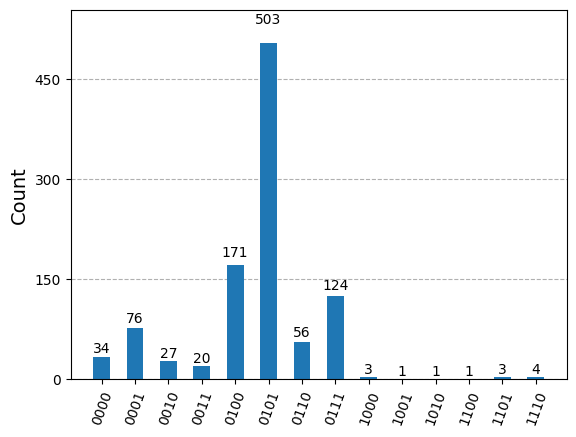

In [13]:
plot_histogram(count)
plt.show()

In [14]:
gamma

[3.141592653589793]

In [15]:
beta

[0.7853981633974483]